# Titanic Data Exploratory Data Analysis (EDA)

This notebook explores the Titanic dataset to understand the factors that influenced survival. We use `matplotlib` and `seaborn` for visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the aesthetic style of the plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
df = pd.read_csv("data.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning
Handling missing values for 'Age' and 'Embarked'.

In [2]:
# Filling missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Checking for remaining missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

## 1. Univariate Analysis
Analyzing individual variables.

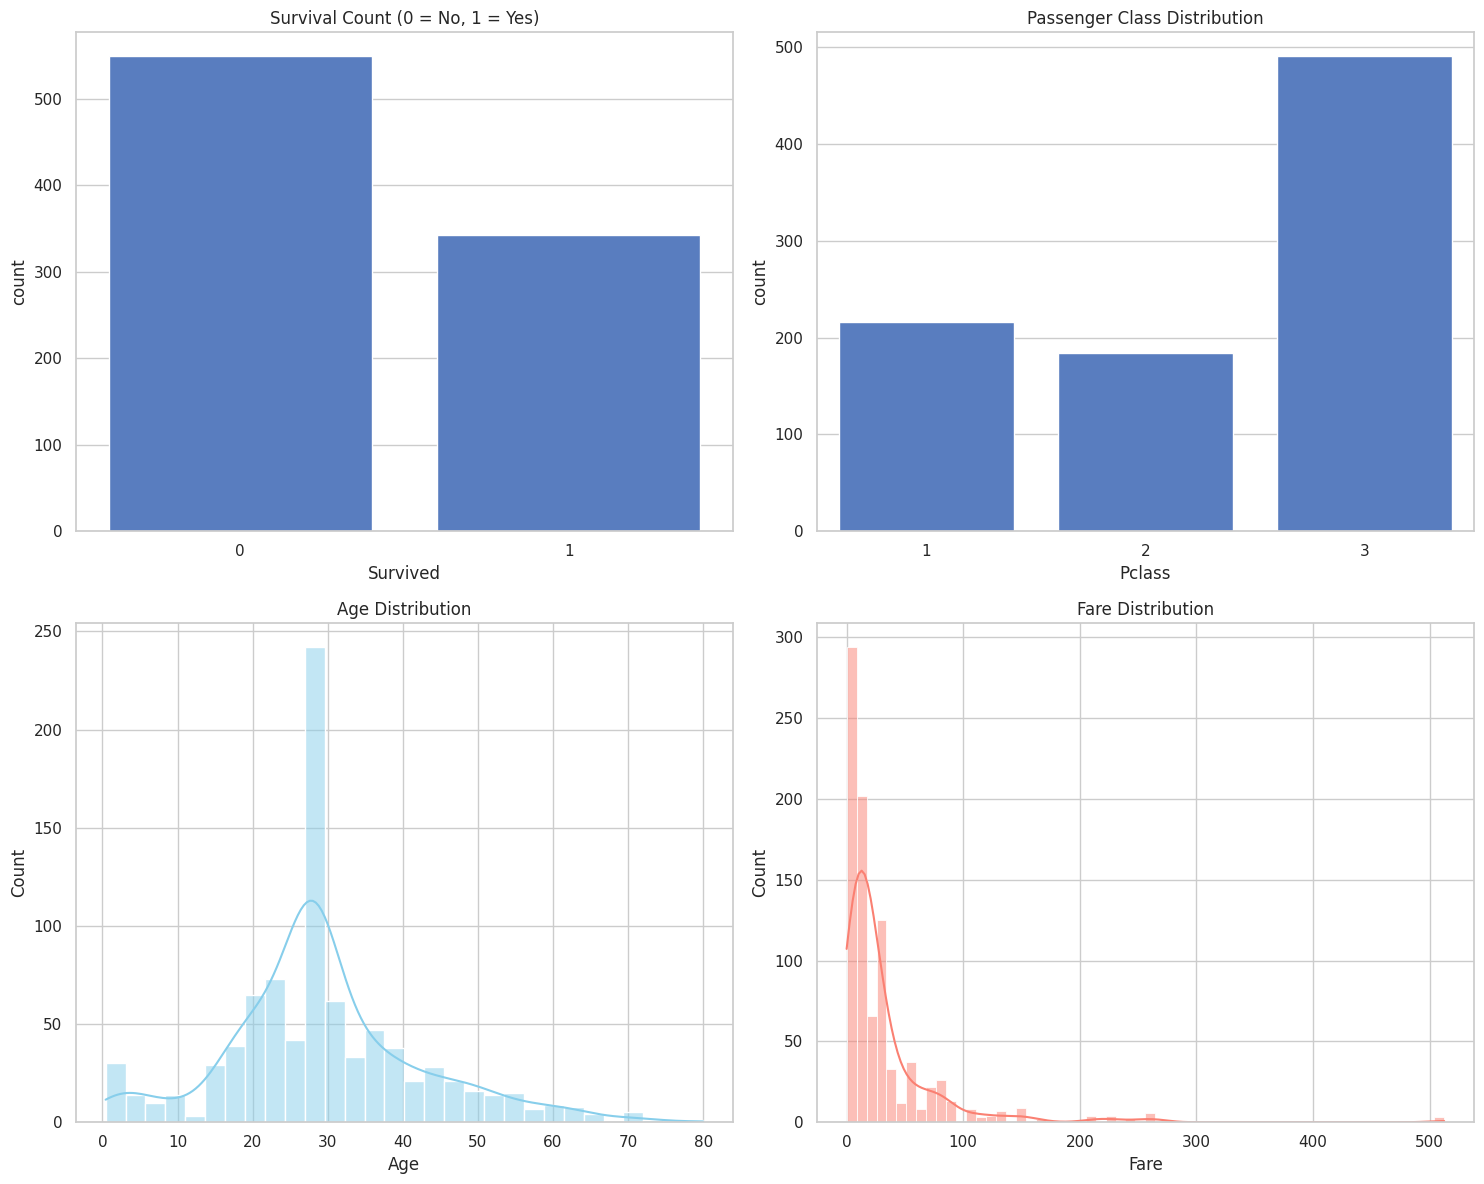

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Survival Count
sns.countplot(x='Survived', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Survival Count (0 = No, 1 = Yes)')

# Pclass Count
sns.countplot(x='Pclass', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Passenger Class Distribution')

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Age Distribution')

# Fare Distribution
sns.histplot(df['Fare'], kde=True, ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

## 2. Bivariate Analysis
Analyzing relationships between variables.

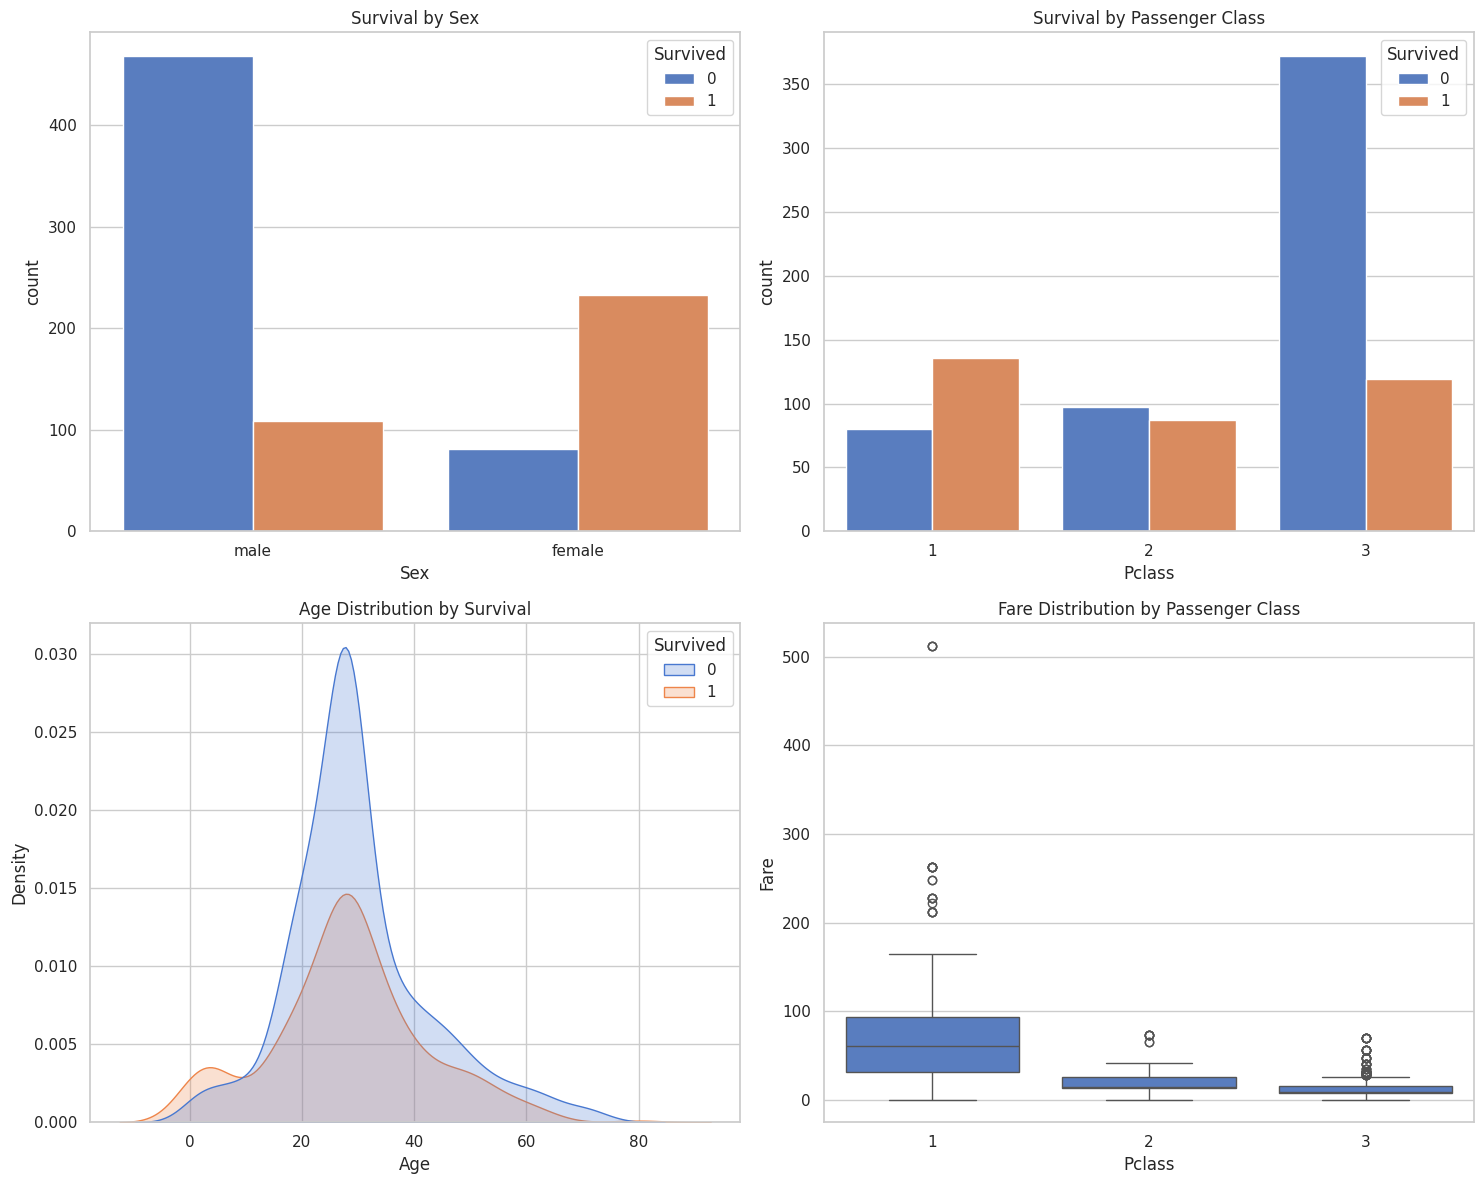

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Survival by Sex
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Survival by Sex')

# Survival by Pclass
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Survival by Passenger Class')

# Age vs Survival
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution by Survival')

# Fare vs Pclass
sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Fare Distribution by Passenger Class')

plt.tight_layout()
plt.show()

## 3. Multivariate Analysis
Analyzing interactions between multiple variables.

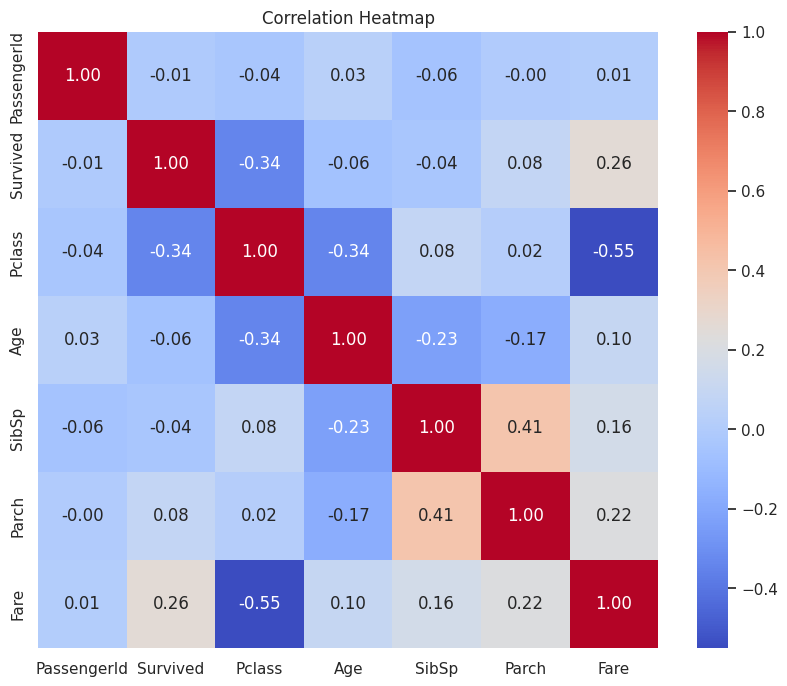

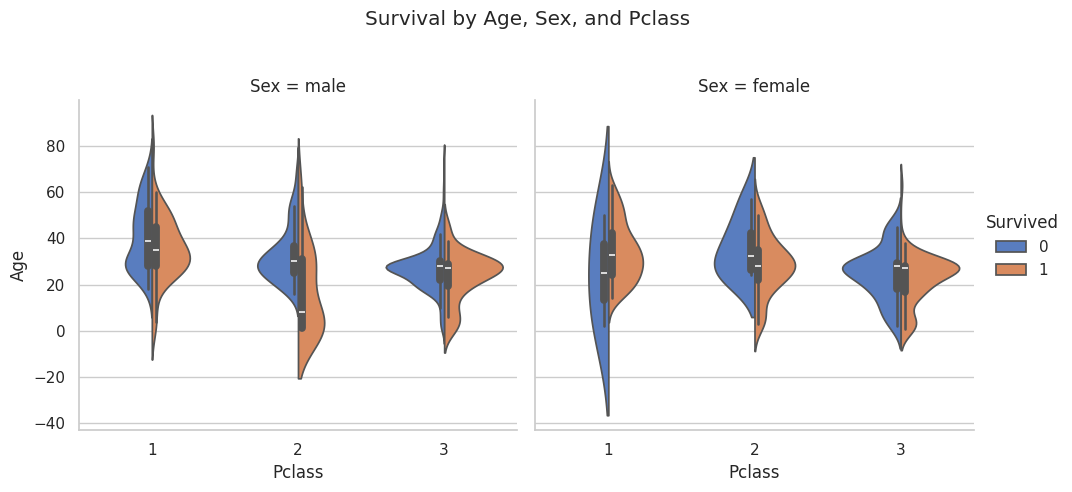

In [5]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Survival by Age, Sex, and Pclass
sns.catplot(x='Pclass', y='Age', hue='Survived', col='Sex', data=df, kind='violin', split=True)
plt.subplots_adjust(top=0.8)
plt.suptitle('Survival by Age, Sex, and Pclass')
plt.show()